#                Assignment

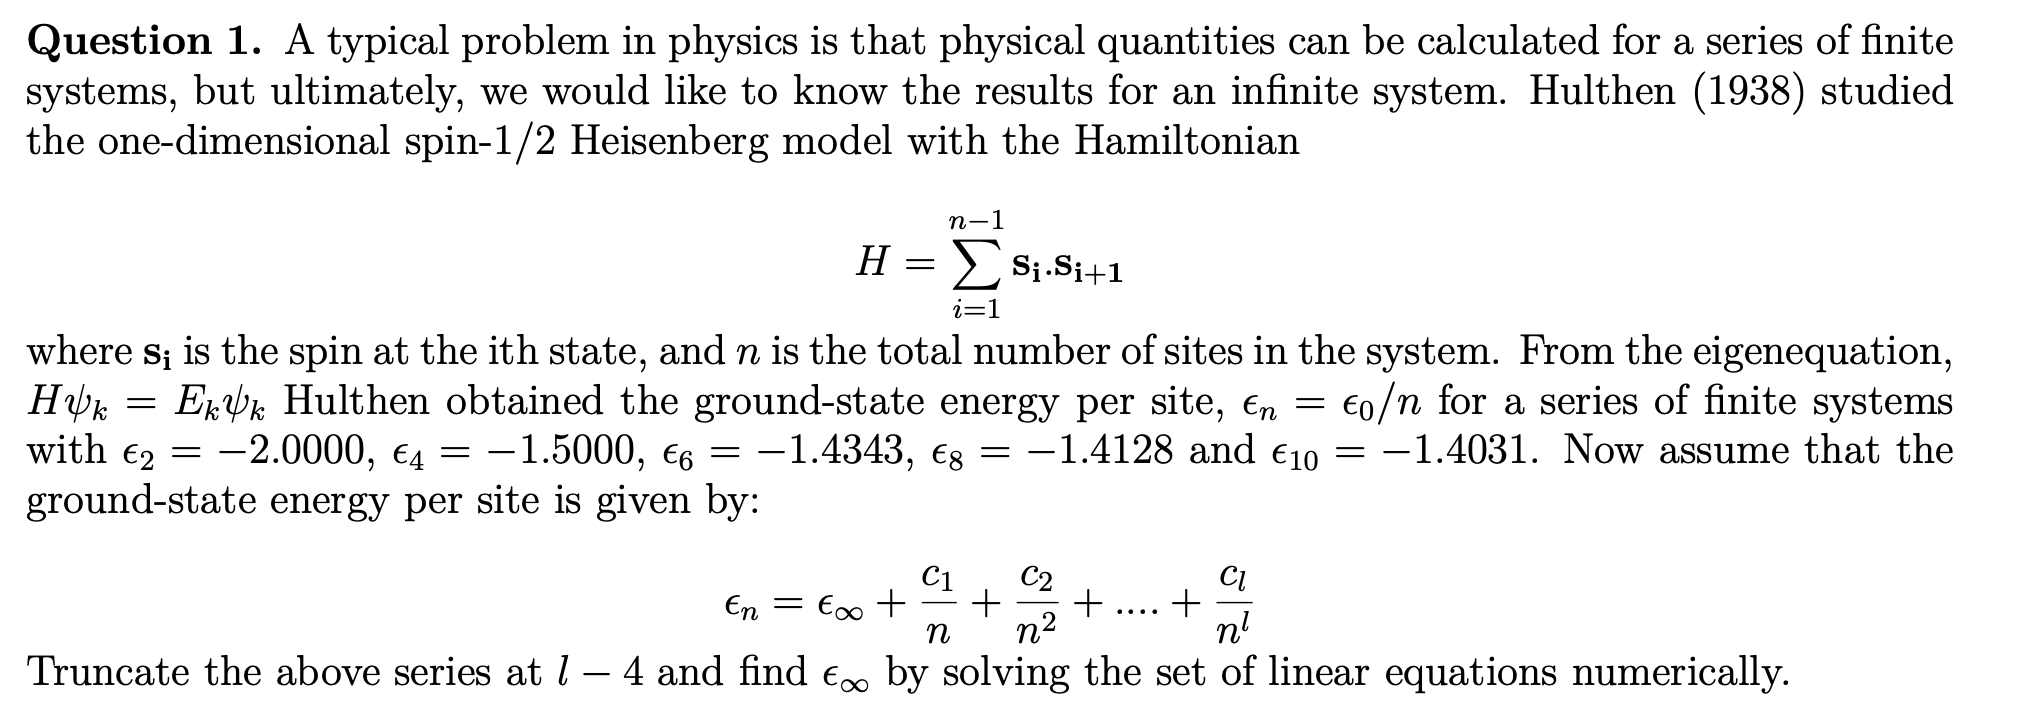

### What we have to do?

1) We have to find the ground state energy per site for an infinite chain, i.e. $\epsilon_\infty$

2) We will use the finite systems known result to extrapolate to $n \rightarrow \infty$


We define the unknown vector:

$X = [\epsilon_\infty , c_1, c_2, c_3, c_4]^T$

Then the system $AX = B$ is:
$$
\begin{bmatrix}
1 & \tfrac{1}{2} & \tfrac{1}{2^2} & \tfrac{1}{2^3} & \tfrac{1}{2^4} \\
1 & \tfrac{1}{4} & \tfrac{1}{4^2} & \tfrac{1}{4^3} & \tfrac{1}{4^4} \\
1 & \tfrac{1}{6} & \tfrac{1}{6^2} & \tfrac{1}{6^3} & \tfrac{1}{6^4} \\
1 & \tfrac{1}{8} & \tfrac{1}{8^2} & \tfrac{1}{8^3} & \tfrac{1}{8^4} \\
1 & \tfrac{1}{10} & \tfrac{1}{10^2} & \tfrac{1}{10^3} & \tfrac{1}{10^4}
\end{bmatrix}
\begin{bmatrix}
\epsilon_\infty \\
c_1 \\
c_2 \\
c_3 \\
c_4
\end{bmatrix}
=
\begin{bmatrix}
-2.0000 \\
-1.5000 \\
-1.4343 \\
-1.4128 \\
-1.4031
\end{bmatrix}
$$


### Easy way to solve it.

In [27]:
import numpy as np 

A = np.array([
    [1, 1/2, 1/4, 1/8, 1/16],
    [1, 1/4, 1/16, 1/64, 1/256],
    [1, 1/6, 1/36, 1/216, 1/1296],
    [1, 1/8, 1/64, 1/512, 1/4096],
    [1, 1/10, 1/100, 1/1000, 1/10000]
])

B = np.array([-2.0000, -1.5000, -1.4343, -1.4128, -1.4031])

X = np.linalg.solve(A, B)
epsilon_inf = X[0]
print(fr"The value of the epsilon_inf is {epsilon_inf:6f}")

The value of the epsilon_inf is -1.387504


### Applying the known technique to solve it

### 1) Cramer's Rule

In [2]:
def cramers_column(A,B, col_indx):
    Ai = A.copy()  # copy A
    Ai[:, col_indx] = B   # replace column
    return Ai

In [3]:
zero = 10**(-12)   # numerical zero defining
A1 = cramers_column(A, B, 0)  # to get the 1st element of X
detA = np.linalg.det(A)
detA1 = np.linalg.det(A1)
if abs(detA) < zero:  
  print("Determinant is (numerically) zero → system unstable")
else:
  X = detA1/detA
  print(fr"the value of the epsilon_inf is {X:6f}")

the value of the epsilon_inf is -1.387504


### 2) Gaussian Elimination ( with pivoting )

In [4]:
def gaussian_elimination_pivot(A, B):
    A = A.astype(float)
    B = B.astype(float)
    n = len(B)
    tol = 1e-12

    # Forward elimination
    for k in range(n):
        # Pivoting
        max_row = k + np.argmax(np.abs(A[k:, k]))
        
        # Check if pivot is effectively zero
        if abs(A[max_row, k]) < tol:
            raise ValueError(f"Matrix is singular or nearly singular at column {k}")
        
        # Swap rows in A and B
        if max_row != k:
            A[[k, max_row]] = A[[max_row, k]]
            B[[k, max_row]] = B[[max_row, k]]

        #  Elimination
        for i in range(k+1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:] = A[i, k:] - factor * A[k, k:]
            B[i] = B[i] - factor * B[k]
    A_upper = A.copy()
    # Back substitution
    X = np.zeros(n)
    for i in range(n-1, -1, -1):
        X[i] = (B[i] - np.dot(A[i, i+1:], X[i+1:])) / A[i, i]

    return X, A_upper

In [5]:
X, A_upper = gaussian_elimination_pivot(A,B)
print(fr"the value of the epsilon_inf is {X[0]:6f}")

the value of the epsilon_inf is -1.387504


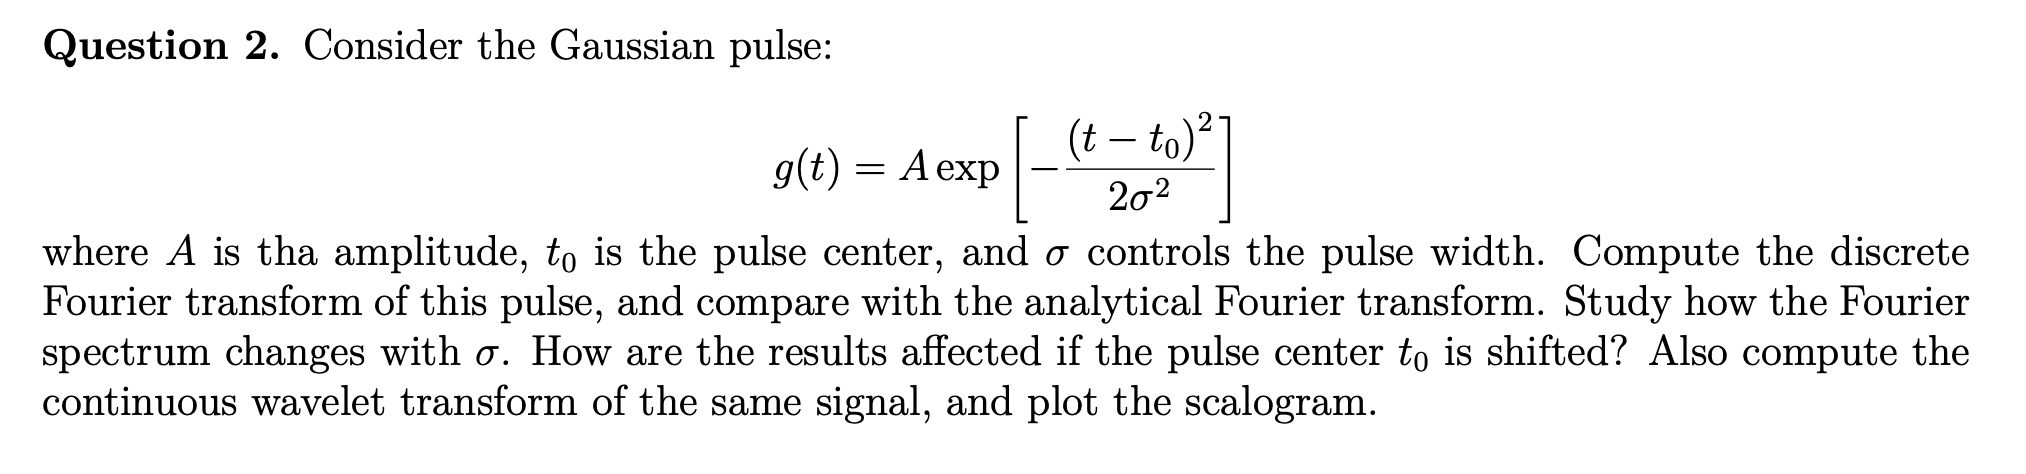

### What needs to be done

1) Compute the discrete Fourier transform $G(\omega)$ of $g(t)$ using FFT and compare with the analytical form $ G(\omega) \propto e^{-\frac{\omega^2 \sigma^2}{2}} e^{-i\omega t_0} $.

2) Verify the Gaussian-to-Gaussian mapping in Fourier space and ensure proper normalization for comparison.

3) Analyze the dependence of spectral width on $\sigma$, illustrating the inverse relation between temporal and frequency spreads.

4) Investigate the effect of time shift $t_0$ and confirm that it introduces only a phase factor $e^{-i\omega t_0}$ without altering the magnitude.

5) Compute the continuous wavelet transform $W(a,b)$ of the signal using an appropriate mother wavelet.

6) Plot the scalogram $|W(a,b)|^2$ and examine localization in time-scale space.

### Gaussian pulse

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift
import pywt 

# Parameters
A = 1.0
t0 = 0.0
sigma = 0.5

# Time grid
N = 1024
T = 10.0
dt = T / N
t = np.linspace(-T/2, T/2, N)

# Gaussian pulse
g = A * np.exp(-(t - t0)**2 / (2 * sigma**2))


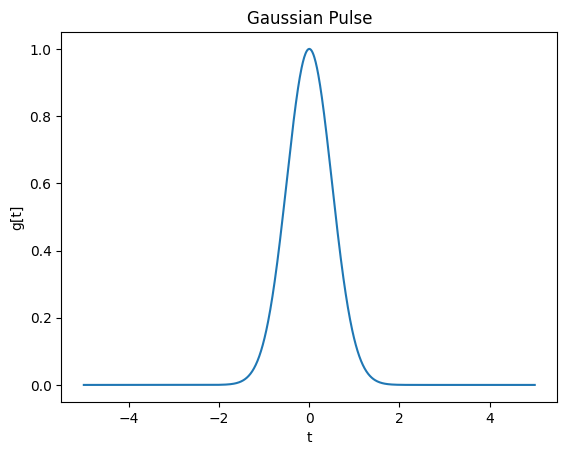

In [16]:
plt.ylabel("g[t]")
plt.xlabel("t")
plt.title("Gaussian Pulse")
plt.plot(t,g)
plt.show()

### Discrete Fourier Transformation

In [17]:
#------------DFT-------------
N1 = len(g)
G_manual = np.zeros(N1, dtype=complex)

for k in range(N1):
    for n in range(N1):
        G_manual[k] += g[n] * np.exp(-2j * np.pi * k * n / N1)
#print(np.abs(G_manual))

G_manual_shifted = np.fft.fftshift(G_manual)
G_manual_mag = np.abs(G_manual_shifted)
#print(G_manual_mag)

# FFT
G = fft(g)
G_shifted = fftshift(G)
#print(G_shifted)

# Frequency axis
freq = fftshift(fftfreq(N, dt))
omega = 2 * np.pi * freq

# Magnitude
G_mag = np.abs(G_shifted)
#print(G_mag)

### Analytical Result


### Derivation of Analytical Fourier Transform

The Gaussian pulse is given by:
$$
g(t) = A \exp\left(-\frac{(t - t_0)^2}{2\sigma^2}\right)
$$

The Fourier transform is:
$$
G(\omega) = \int_{-\infty}^{\infty} g(t)\, e^{-i\omega t}\, dt
$$

Substituting:
$$
G(\omega) = A \int_{-\infty}^{\infty}
\exp\left(-\frac{(t - t_0)^2}{2\sigma^2} - i\omega t\right) dt
$$

Expanding:
$$
(t - t_0)^2 = t^2 - 2t t_0 + t_0^2
$$

$$
G(\omega) = A \int_{-\infty}^{\infty}
\exp\left(-\frac{t^2}{2\sigma^2} + \frac{t t_0}{\sigma^2} - \frac{t_0^2}{2\sigma^2} - i\omega t\right) dt
$$

Grouping terms:
$$
= A \int_{-\infty}^{\infty}
\exp\left(-\frac{t^2}{2\sigma^2} + t\left(\frac{t_0}{\sigma^2} - i\omega\right) - \frac{t_0^2}{2\sigma^2}\right) dt
$$

Let:
$$
\alpha = \frac{t_0}{\sigma^2} - i\omega
$$

Complete the square:
$$
= A \exp\left(-\frac{t_0^2}{2\sigma^2}\right)
\int_{-\infty}^{\infty}
\exp\left(-\frac{1}{2\sigma^2}(t - \sigma^2 \alpha)^2 + \frac{\sigma^2 \alpha^2}{2}\right) dt
$$

Take constants out:
$$
G(\omega) =
A \exp\left(\frac{\sigma^2 \alpha^2}{2} - \frac{t_0^2}{2\sigma^2}\right)
\int_{-\infty}^{\infty}
\exp\left(-\frac{(t - \sigma^2 \alpha)^2}{2\sigma^2}\right) dt
$$

Using:
$$
\int_{-\infty}^{\infty}
e^{-\frac{(t - \mu)^2}{2\sigma^2}} dt = \sqrt{2\pi}\,\sigma
$$

$$
G(\omega) =
A \sqrt{2\pi}\,\sigma \;
\exp\left(\frac{\sigma^2 \alpha^2}{2} - \frac{t_0^2}{2\sigma^2}\right)
$$

Now simplify:
$$
\sigma^2 \alpha^2 =
\frac{t_0^2}{\sigma^2} - 2i\omega t_0 - \sigma^2 \omega^2
$$

$$
\Rightarrow
\frac{\sigma^2 \alpha^2}{2} - \frac{t_0^2}{2\sigma^2}
= -i\omega t_0 - \frac{\sigma^2 \omega^2}{2}
$$

$$
\boxed{
G(\omega) =
A \sigma \sqrt{2\pi}\;
\exp\left(-\frac{\sigma^2 \omega^2}{2}\right)
\exp(-i\omega t_0)
}
$$

In [18]:
G_analytical = A * sigma * np.sqrt(2*np.pi) * np.exp(-(omega**2 * sigma**2)/2)

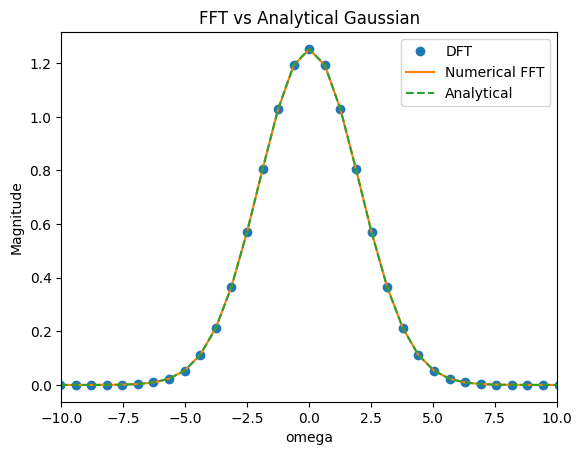

In [19]:
plt.figure()
plt.plot(omega, G_manual_mag*dt, 'o', label='DFT')
plt.plot(omega, G_mag*dt, label='Numerical FFT')
plt.plot(omega, G_analytical, '--', label='Analytical')
plt.xlabel('omega')
plt.ylabel('Magnitude')
plt.xlim(-10,10)
#plt.ylim(0,1.3)
plt.legend()
plt.title('FFT vs Analytical Gaussian')
plt.show()

### Effect of $\sigma$

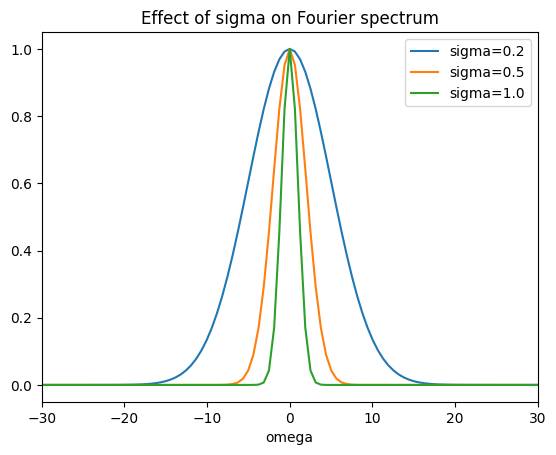

In [20]:
sigmas = [0.2, 0.5, 1.0]

plt.figure()

for s in sigmas:
    g = np.exp(-(t**2)/(2*s**2))
    G = fftshift(fft(g))
    plt.plot(omega, np.abs(G)/np.max(np.abs(G)), label=f'sigma={s}')
plt.xlim(-30,30)
plt.legend()
plt.title('Effect of sigma on Fourier spectrum')
plt.xlabel('omega')
plt.show()

### Analysis

1) As $\sigma$ increases, the Fourier spectrum becomes narrower in frequency space.
2) As $\sigma$ decreases, the spectrum becomes broader.
3) All curves peak at $\omega = 0$, indicating that the dominant contribution is from low-frequency components.

### Effect of $t_0$ shift

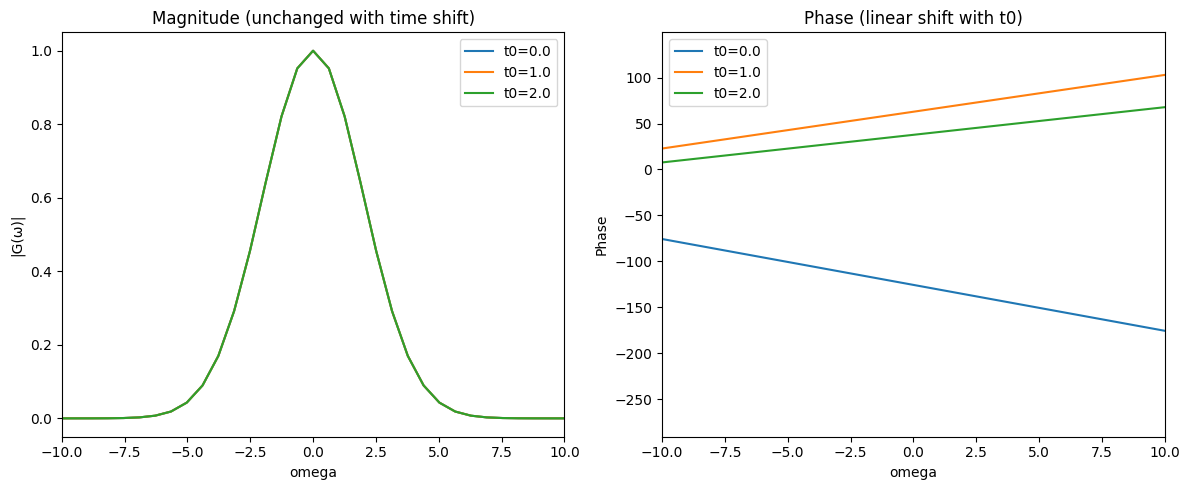

In [24]:
t0_values = [0.0, 1.0, 2.0]

plt.figure(figsize=(12,5))

# -------- Magnitude --------
plt.subplot(1,2,1)
for t0 in t0_values:
    g = np.exp(-(t - t0)**2 / (2*sigma**2))
    G = fftshift(fft(g)) * dt
    plt.plot(omega, np.abs(G)/np.max(np.abs(G)), label=f't0={t0}')

plt.xlim(-10,10)
plt.title('Magnitude (unchanged with time shift)')
plt.xlabel('omega')
plt.ylabel('|G(ω)|')
plt.legend()

# -------- Phase --------
plt.subplot(1,2,2)
for t0 in t0_values:
    g = np.exp(-(t - t0)**2 / (2*sigma**2))
    G = fftshift(fft(g)) * dt
    phase = np.unwrap(np.angle(G))
    plt.plot(omega, phase, label=f't0={t0}')

plt.xlim(-10,10)
plt.title('Phase (linear shift with t0)')
plt.xlabel('omega')
plt.ylabel('Phase')
plt.legend()

plt.tight_layout()
plt.show()

### Analysis

1) The magnitude of the spectrum remains unchanged for all values of $t_0$.
2) All curves perfectly overlap, indicating identical spectral amplitudes.
3) The peak remains centered at $\omega = 0$ regardless of the shift.
4) The phase varies linearly with frequency as $\phi(\omega)=−\omega t_0$
, confirming that a time shift introduces only a phase change without altering the spectral magnitude.

In [28]:
# Use Morlet wavelet
scales = np.arange(1, 128)

coefficients, frequencies = pywt.cwt(g, scales, 'morl', sampling_period=dt)

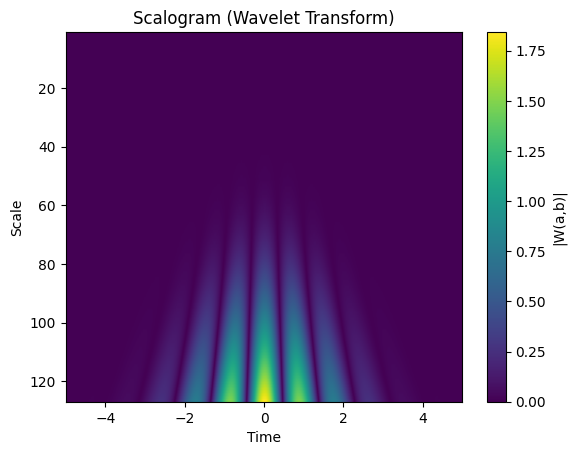

In [29]:
plt.figure()

plt.imshow(np.abs(coefficients), 
           extent=[t.min(), t.max(), scales.max(), scales.min()],
           aspect='auto')

plt.colorbar(label='|W(a,b)|')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.title('Scalogram (Wavelet Transform)')
plt.show()

### Analysis
The scalogram reveals that the signal energy is localized around $t_0$ and spread across scales depending on $\sigma$, illustrating the time–scale trade-off and confirming the localized nature of the Gaussian pulse.